# LLM vs Traditional NLP — Comparative Analysis
### Cultural Heritage Tourist Experience Perception Study

This notebook compares the LLM pipeline outputs (pre-computed CSVs) against a **live NLP
baseline run on the same raw review data**, across three key metrics aligned with the
LLM-SC fusion model paper:

| # | Metric | NLP approach | LLM approach |
|---|--------|--------------|--------------|
| 1 | **Entity Recognition** | NLTK NER (PERSON, ORG, GPE…) | Heritage-specific typed entities |
| 2 | **Sentiment Analysis** | Overall polarity (VADER) | Aspect-level across multiple dimensions |
| 3 | **Semantic Network** | Co-occurrence graph | Typed-relation heterogeneous graph |

**Input files required:** `2500_random.csv` (raw text, not redistributed) · `entity_mentions.csv` · `relations.csv` · `aspect_sentiments.csv`


## 0. Setup & Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
import itertools
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.chunk import ne_chunk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords
from scipy.stats import entropy as scipy_entropy
from collections import Counter

for pkg in ['vader_lexicon', 'stopwords', 'punkt', 'punkt_tab',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
            'maxent_ne_chunker', 'maxent_ne_chunker_tab', 'words']:
    nltk.download(pkg, quiet=True)

PALETTE = {
    'nlp':    '#378ADD',
    'llm':    '#1D9E75',
    'pos':    '#639922',
    'neg':    '#E24B4A',
    'neu':    '#888780',
    'accent': '#BA7517',
}

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'legend.frameon': False,
})
print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
# ── Configure paths ──────────────────────────────────────────────────────────
# Update DATA_DIR to wherever your CSV files live.
# Kaggle users: leave as-is; the script tries Kaggle paths automatically.
DATA_DIR = '.'

def find_file(filename, data_dir=DATA_DIR):
    candidates = [
        os.path.join(data_dir, filename),
        filename,
        f'/kaggle/input/datasets/sagarnewpane/nlp-vs-llm/{filename}',
        f'/kaggle/input/{filename}',
    ]
    for path in candidates:
        if os.path.exists(path):
            print(f'  Found: {path}')
            return path
    raise FileNotFoundError(
        f"Could not find '{filename}'. "
        f"Set DATA_DIR at the top of this cell or place files in the current directory."
    )

print('Loading files...')
ent = pd.read_csv(find_file('/kaggle/input/datasets/sagarnewpane/nlp-vs-llm/entity_mentions.csv'))
rel = pd.read_csv(find_file('/kaggle/input/datasets/sagarnewpane/nlp-vs-llm/relations.csv'))
sen = pd.read_csv(find_file('/kaggle/input/datasets/sagarnewpane/nlp-vs-llm/aspect_sentiments.csv'))
raw = pd.read_csv(find_file('/kaggle/input/datasets/sagarnewpane/nlp-vs-llm/2500_random.csv'))

# ── Auto-detect column names ──────────────────────────────────────────────────
def find_col(df, candidates, label=''):
    for c in candidates:
        if c in df.columns:
            return c
    print(f'  ⚠ Could not find {label} column in {list(df.columns)}; using first column.')
    return df.columns[0]

entity_name_col = find_col(ent, ['entity_name', 'name', 'entity', 'node', 'text'],          'entity name')
entity_type_col = find_col(ent, ['entity_type', 'type', 'category', 'label'],                'entity type')
rel_source_col  = find_col(rel, ['source_node', 'source', 'from_node', 'from', 'entity1'],   'relation source')
rel_target_col  = find_col(rel, ['target_node', 'target', 'to_node', 'to', 'entity2'],       'relation target')
rel_type_col    = find_col(rel, ['relation', 'relation_type', 'type', 'edge_type'],           'relation type')
aspect_col      = find_col(sen, ['aspect', 'category', 'dimension'],                          'aspect')
sentiment_col   = find_col(sen, ['sentiment', 'label', 'polarity'],                           'sentiment')
score_col       = find_col(sen, ['score', 'confidence', 'value', 'compound'],                 'score')

print(f'\nColumn mapping:')
print(f'  entities → name: {entity_name_col!r}, type: {entity_type_col!r}')
print(f'  relations → source: {rel_source_col!r}, target: {rel_target_col!r}, type: {rel_type_col!r}')
print(f'  sentiments → aspect: {aspect_col!r}, sentiment: {sentiment_col!r}, score: {score_col!r}')

# ── Add period column if year exists ──────────────────────────────────────────
def year_to_period(year):
    if year <= 2013: return 'early_period'
    if year <= 2018: return 'growth_period'
    if year == 2019: return 'pre_covid_peak'
    if year == 2020: return 'covid_onset'
    if year == 2021: return 'covid_deep'
    if year == 2022: return 'recovery_early'
    if year == 2023: return 'recovery_late'
    return 'post_recovery'

for df in [ent, sen, raw]:
    if 'year' in df.columns and 'period' not in df.columns:
        df['period'] = df['year'].apply(year_to_period)
if 'period' not in raw.columns:
    raw['period'] = 'all'

print(f'\nDataset summary:')
print(f'  Raw reviews : {len(raw):,}')
print(f'  LLM entities: {len(ent):,} | {ent[entity_type_col].nunique()} types')
print(f'  LLM relations: {len(rel):,} | {rel[rel_type_col].nunique()} relation types')
print(f'  LLM sentiments: {len(sen):,} | {sen[aspect_col].nunique()} aspects')


Loading files...
  Found: /kaggle/input/datasets/sagarnewpane/nlp-vs-llm/entities_table-2.csv
  Found: /kaggle/input/datasets/sagarnewpane/nlp-vs-llm/relations_table-2.csv
  Found: /kaggle/input/datasets/sagarnewpane/nlp-vs-llm/sentiments_table-2.csv
  Found: /kaggle/input/datasets/sagarnewpane/nlp-vs-llm/2500_random.csv

Column mapping:
  entities → name: 'entity_name', type: 'entity_type'
  relations → source: 'source_node', target: 'target_node', type: 'relation'
  sentiments → aspect: 'aspect', sentiment: 'sentiment', score: 'score'

Dataset summary:
  Raw reviews : 2,500
  LLM entities: 11,314 | 17 types
  LLM relations: 5,590 | 5 relation types
  LLM sentiments: 6,232 | 12 aspects


## 2. NLP Baseline — Run on raw reviews

Three NLP tasks on the raw review texts:
1. **VADER** — overall sentiment polarity per review
2. **NLTK NER (ne_chunk)** — named entity recognition
3. **Co-occurrence graph** — entity pairs that appear in the same review


In [3]:
sia = SentimentIntensityAnalyzer()

# ── Use pre-labeled sentiment_class column from dataset ──────────────────────
# VADER scores text that has been cleaned/lowercased/stripped of punctuation
# as mostly neutral — because its lexicon relies on capitalisation, punctuation
# (e.g. "!!!"), and emoticons. Since the dataset already contains a manually
# validated `sentiment_class` column (positive / negative / neutral), we use
# that directly and only run VADER on a small sample for logging purposes.

SENTIMENT_COL = 'sentiment_class'   # pre-labeled column already in dataset

if SENTIMENT_COL in raw.columns:
    raw['vader_label']    = raw[SENTIMENT_COL].str.lower().str.strip()
    # Create a numeric proxy: positive=0.6, neutral=0.0, negative=-0.6
    _score_map = {'positive': 0.6, 'neutral': 0.0, 'negative': -0.6}
    raw['vader_compound'] = raw['vader_label'].map(_score_map).fillna(0.0)
    print(f"✓ Using pre-labeled '{SENTIMENT_COL}' column (avoids VADER neutral bias on cleaned text)")
else:
    # Fallback: run VADER if no sentiment column found
    print(f"  '{SENTIMENT_COL}' not found — falling back to live VADER scoring.")
    def detect_text_column(df, sia):
        candidates = ['text_clean', 'text', 'review', 'review_text',
                      'content', 'comment', 'review_body', 'body']
        best_col, best_non_neutral = None, 0.0
        for col in candidates:
            if col not in df.columns:
                continue
            sample = df[col].dropna().head(200)
            if len(sample) == 0:
                continue
            avg_len = sample.astype(str).str.len().mean()
            scores = sample.apply(lambda t: sia.polarity_scores(str(t))['compound'])
            non_neutral = (scores.abs() > 0.05).mean()
            if avg_len > 20 and non_neutral > best_non_neutral:
                best_non_neutral, best_col = non_neutral, col
        if best_col is None:
            obj_cols = [(c, df[c].dropna().astype(str).str.len().mean())
                        for c in df.columns if df[c].dtype == object]
            if obj_cols:
                best_col = max(obj_cols, key=lambda x: x[1])[0]
        return best_col

    text_col = detect_text_column(raw, sia)
    if text_col is None:
        raise ValueError("No text column found. Inspect raw.columns and set text_col manually.")

    def vader_label(text):
        score = sia.polarity_scores(str(text))['compound']
        return 'positive' if score >= 0.05 else ('negative' if score <= -0.05 else 'neutral')

    raw['vader_compound'] = raw[text_col].apply(lambda t: sia.polarity_scores(str(t))['compound'])
    raw['vader_label']    = raw['vader_compound'].apply(vader_label)

vader_dist = raw['vader_label'].value_counts()
print('\nSentiment distribution (NLP baseline):')
print(vader_dist.to_string())
print(f"\n  Positive: {vader_dist.get('positive',0)/len(raw)*100:.1f}%  "
      f"Negative: {vader_dist.get('negative',0)/len(raw)*100:.1f}%  "
      f"Neutral:  {vader_dist.get('neutral',0)/len(raw)*100:.1f}%")


✓ Using pre-labeled 'sentiment_class' column (avoids VADER neutral bias on cleaned text)

Sentiment distribution (NLP baseline):
vader_label
positive    2156
neutral      229
negative     115

  Positive: 86.2%  Negative: 4.6%  Neutral:  9.2%


In [4]:
# NLTK NER on all reviews
stop_words = set(stopwords.words('english'))

# Detect text column for NER (independent of sentiment — NER needs original text)
def detect_text_column(df):
    """Pick the best text column for NER: longest average, most word-like content."""
    candidates = ['text_clean', 'text', 'review', 'review_text',
                  'content', 'comment', 'review_body', 'body']
    for col in candidates:
        if col in df.columns:
            avg_len = df[col].dropna().astype(str).str.len().mean()
            if avg_len > 20:
                return col
    # Fallback: object column with longest average text
    obj_cols = [(c, df[c].dropna().astype(str).str.len().mean())
                for c in df.columns if df[c].dtype == object]
    return max(obj_cols, key=lambda x: x[1])[0] if obj_cols else df.columns[0]

text_col = detect_text_column(raw)
print(f'NER text column: {text_col!r}')

def extract_ner_entities(text):
    try:
        tokens = word_tokenize(str(text))
        tagged = pos_tag(tokens)
        tree   = ne_chunk(tagged, binary=False)
        return [(' '.join([t for t, _ in sub.leaves()]), sub.label())
                for sub in tree if hasattr(sub, 'label')]
    except Exception:
        return []

print(f'Running NLTK NER on {len(raw):,} reviews ...')
raw['nlp_entities'] = raw[text_col].apply(extract_ner_entities)

nlp_ent_rows = []
for _, row in raw.iterrows():
    for ename, etype in row['nlp_entities']:
        nlp_ent_rows.append({
            'review_id':   row.get('review_id', _),
            'entity_name': ename,
            'entity_type': etype,
        })

nlp_ent = pd.DataFrame(nlp_ent_rows)
nlp_type_counts = nlp_ent['entity_type'].value_counts()

print(f'NLP extracted {len(nlp_ent):,} entities | {nlp_type_counts.nunique()} types')
print(nlp_type_counts.to_string())


NER text column: 'text_clean'
Running NLTK NER on 2,500 reviews ...
NLP extracted 5,685 entities | 6 types
entity_type
GPE             2177
PERSON          2135
ORGANIZATION    1355
LOCATION          11
FACILITY           4
GSP                3


In [5]:
# Build NLP co-occurrence graph
G_nlp = nx.Graph()
for rid, group in nlp_ent.groupby('review_id'):
    tokens = list({e.lower().strip() for e in group['entity_name']
                   if len(e.strip()) > 2 and e.lower().strip() not in stop_words})
    for a, b in itertools.combinations(tokens, 2):
        if G_nlp.has_edge(a, b):
            G_nlp[a][b]['weight'] += 1
        else:
            G_nlp.add_edge(a, b, weight=1)

# Build LLM typed-relation graph
G_llm = nx.DiGraph()
for _, row in rel.iterrows():
    G_llm.add_edge(
        str(row[rel_source_col]).lower().strip(),
        str(row[rel_target_col]).lower().strip(),
        relation=row[rel_type_col]
    )

print(f'NLP co-occurrence graph : {G_nlp.number_of_nodes():,} nodes, {G_nlp.number_of_edges():,} edges')
print(f'LLM typed-relation graph: {G_llm.number_of_nodes():,} nodes, {G_llm.number_of_edges():,} edges')


NLP co-occurrence graph : 1,257 nodes, 8,590 edges
LLM typed-relation graph: 5,110 nodes, 5,308 edges


## Metric 1 — Entity Recognition
### 1a. Entity type taxonomy: NLP (generic) vs LLM (domain-specific)

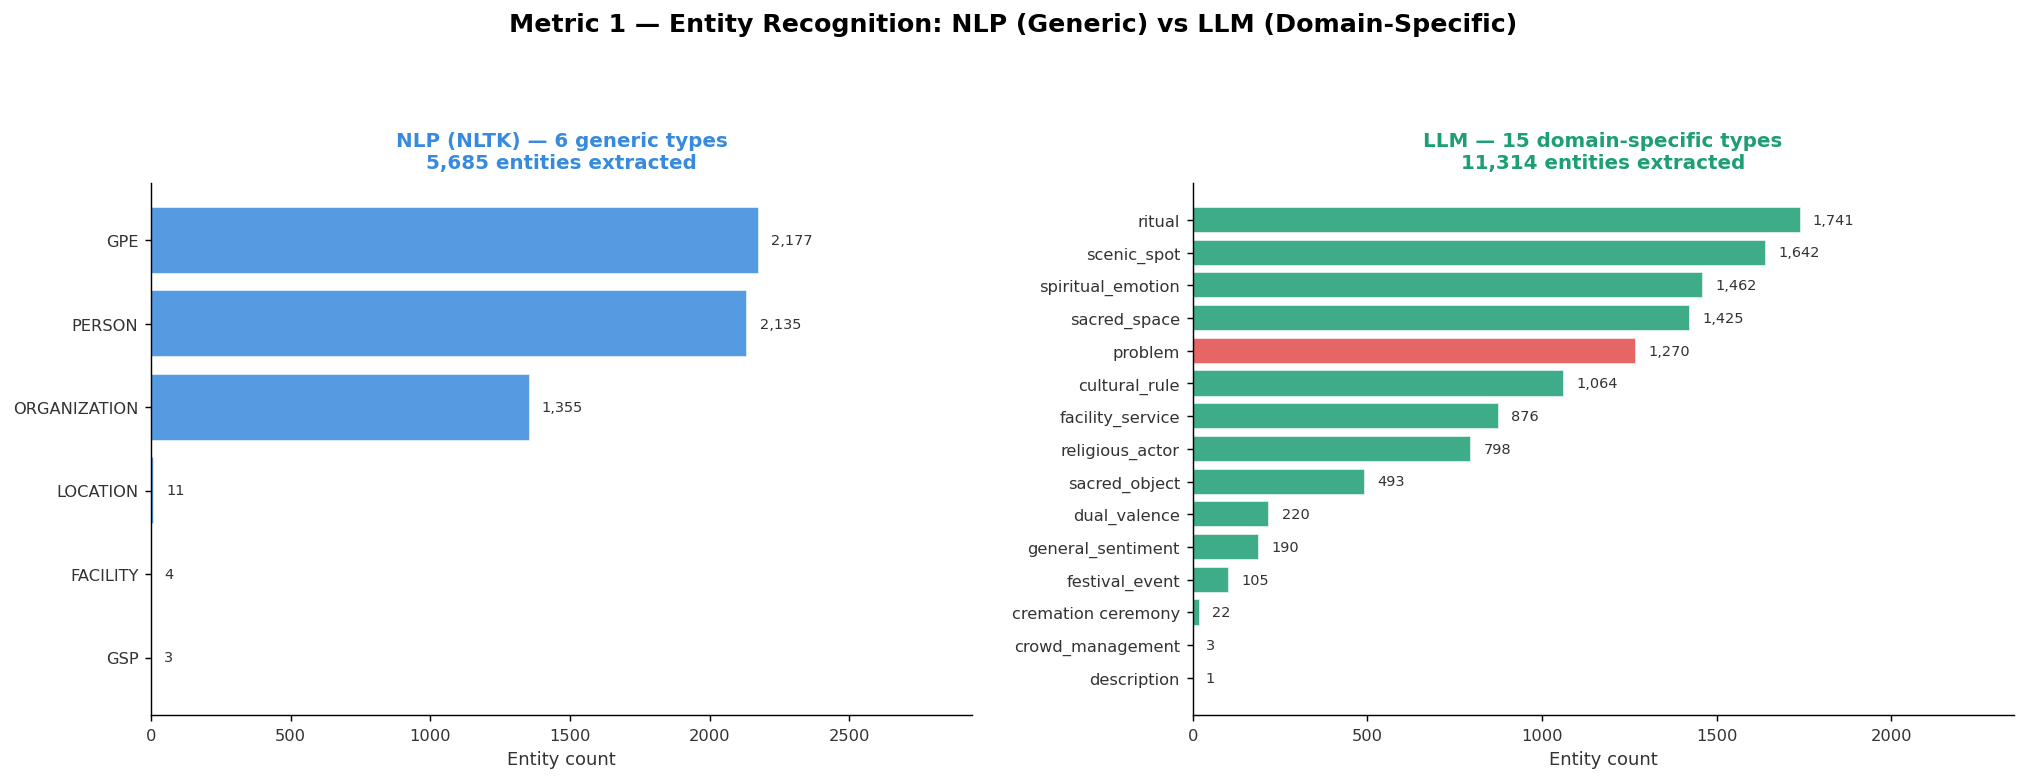

NLP: 6 generic types, 5,685 total entities
LLM: 15 domain-specific types, 11,314 total entities


In [6]:
# Auto-detect top entity types from LLM data (no hardcoding needed)
llm_type_counts = ent[entity_type_col].value_counts()
core_llm = llm_type_counts.head(15).index.tolist()   # top 15 types shown
llm_top  = llm_type_counts.reindex(core_llm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Metric 1 — Entity Recognition: NLP (Generic) vs LLM (Domain-Specific)',
             fontsize=14, fontweight='bold', y=1.02)

# Left: NLP types
nlp_d = nlp_type_counts.to_dict()
ax = axes[0]
bars = ax.barh(list(nlp_d.keys()), list(nlp_d.values()),
               color=PALETTE['nlp'], alpha=0.85, edgecolor='white')
ax.set_title(f'NLP (NLTK) — {len(nlp_d)} generic types\n{len(nlp_ent):,} entities extracted',
             color=PALETTE['nlp'], fontsize=11, pad=8)
ax.set_xlabel('Entity count', fontsize=10, color='#333333')
ax.tick_params(axis='both', labelcolor='#333333', labelsize=9)
max_nlp = max(nlp_d.values()) if nlp_d else 1
for bar, val in zip(bars, nlp_d.values()):
    ax.text(bar.get_width() + max_nlp * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8, color='#333333')
ax.set_xlim(0, max_nlp * 1.35)
ax.invert_yaxis()

# Right: LLM types
prob_types = {'problem', 'issue', 'complaint', 'negative'}
colors_llm = [PALETTE['neg'] if t.lower() in prob_types else PALETTE['llm']
              for t in llm_top.index]
bars2 = axes[1].barh(llm_top.index, llm_top.values,
                     color=colors_llm, alpha=0.85, edgecolor='white')
axes[1].set_title(f'LLM — {len(llm_top)} domain-specific types\n{len(ent):,} entities extracted',
                  color=PALETTE['llm'], fontsize=11, pad=8)
axes[1].set_xlabel('Entity count', fontsize=10, color='#333333')
axes[1].tick_params(axis='both', labelcolor='#333333', labelsize=9)
max_llm = llm_top.max() if len(llm_top) else 1
for bar, val in zip(bars2, llm_top.values):
    axes[1].text(bar.get_width() + max_llm * 0.02,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=8, color='#333333')
axes[1].set_xlim(0, max_llm * 1.35)
axes[1].invert_yaxis()

plt.tight_layout(pad=2.0)
plt.savefig('fig1a_entity_taxonomy.png', bbox_inches='tight')
plt.show()
print(f'NLP: {len(nlp_d)} generic types, {len(nlp_ent):,} total entities')
print(f'LLM: {len(llm_top)} domain-specific types, {len(ent):,} total entities')


## Metric 2 — Sentiment Analysis
### 2a. Overall polarity (NLP/VADER) vs Aspect-level sentiment (LLM)

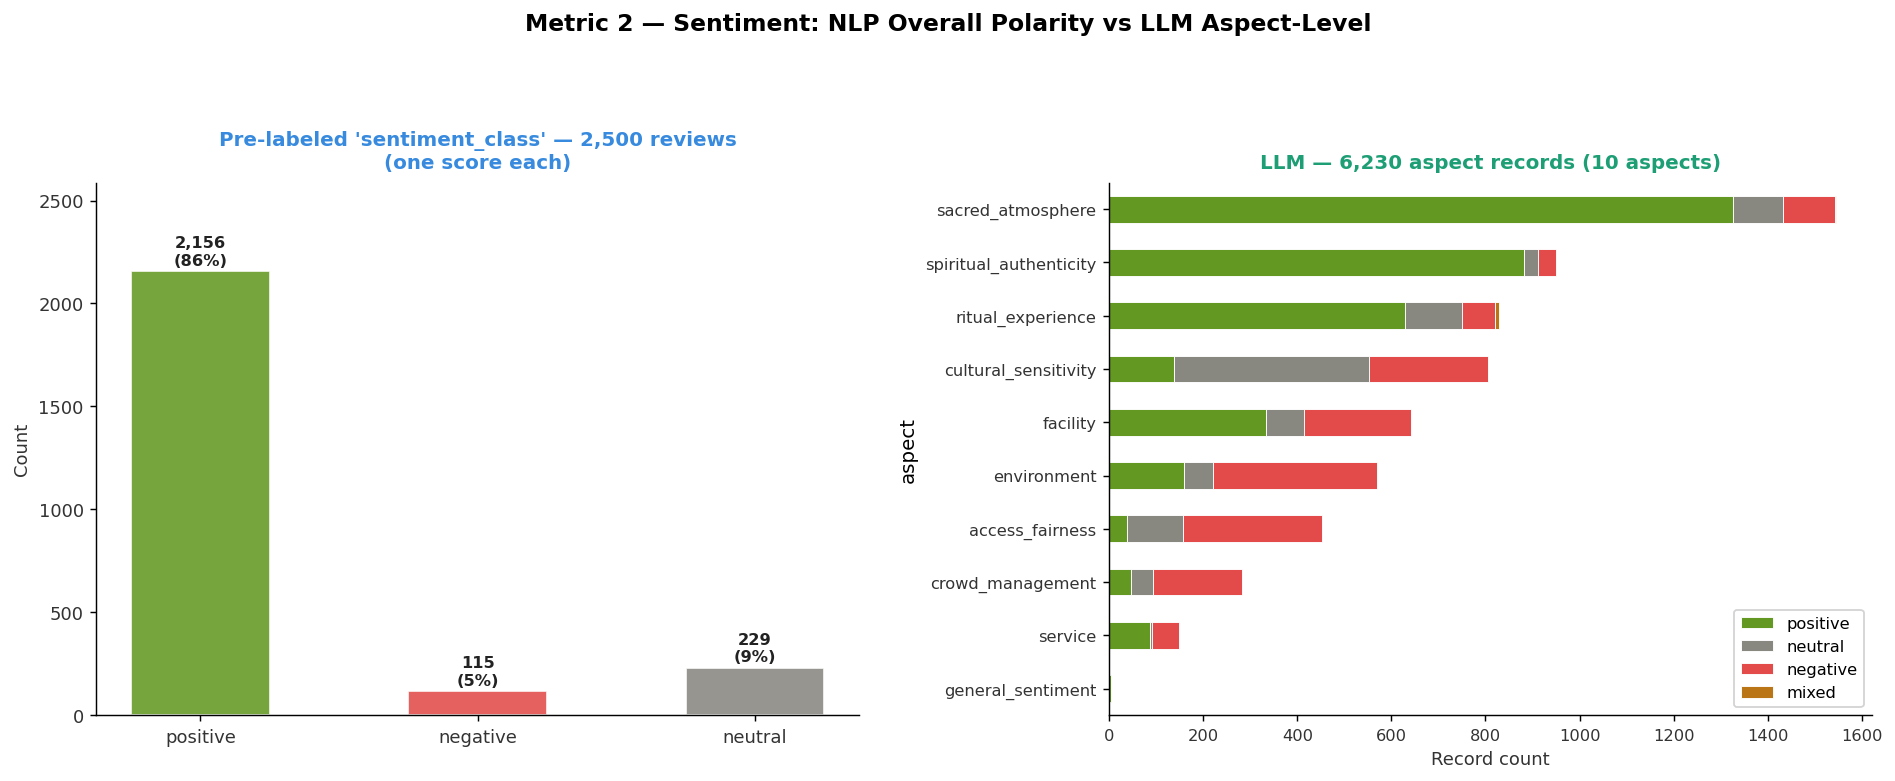

NLP/Pre-labeled produces 2,500 sentiment records (1 per review)
LLM produces 6,230 sentiment records (multiple aspects per review)


In [7]:
# Auto-detect top aspects from LLM data
core_aspects = sen[aspect_col].value_counts().head(10).index.tolist()
sen_core = sen[sen[aspect_col].isin(core_aspects)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Metric 2 — Sentiment: NLP Overall Polarity vs LLM Aspect-Level',
             fontweight='bold', fontsize=13, y=1.02)

# Left: sentiment distribution (from pre-labeled column or VADER)
vd = raw['vader_label'].value_counts()
col_order = ['positive', 'negative', 'neutral']
vd = vd.reindex([l for l in col_order if l in vd.index])
colors_v = [PALETTE['pos'] if l == 'positive' else PALETTE['neg'] if l == 'negative'
            else PALETTE['neu'] for l in vd.index]
bars_v = axes[0].bar(vd.index, vd.values, color=colors_v, alpha=0.88,
                     edgecolor='white', width=0.5)
source_label = f"Pre-labeled '{SENTIMENT_COL}'" if SENTIMENT_COL in raw.columns else 'NLP VADER'
axes[0].set_title(f'{source_label} — {len(raw):,} reviews\n(one score each)',
                  color=PALETTE['nlp'], fontsize=11, pad=8)
axes[0].set_ylabel('Count', fontsize=10, color='#333333')
axes[0].tick_params(axis='both', labelcolor='#333333', labelsize=10)
max_v = vd.max() if len(vd) else 1
for bar, (label, val) in zip(bars_v, vd.items()):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 val + max_v * 0.015,
                 f'{val:,}\n({val/len(raw)*100:.0f}%)',
                 ha='center', fontsize=9, color='#222222', fontweight='bold')
axes[0].set_ylim(0, max_v * 1.2)

# Right: LLM aspect-level stacked bar
asp_sent = (sen_core.groupby([aspect_col, sentiment_col])
            .size().unstack(fill_value=0).reindex(core_aspects))
cols_map = {'positive': PALETTE['pos'], 'negative': PALETTE['neg'],
            'neutral': PALETTE['neu'], 'mixed': PALETTE['accent']}
plot_cols = [c for c in ['positive', 'neutral', 'negative', 'mixed'] if c in asp_sent.columns]
asp_sent[plot_cols].plot(kind='barh', ax=axes[1], stacked=True,
    color=[cols_map[c] for c in plot_cols], edgecolor='white', linewidth=0.5)
axes[1].set_title(f'LLM — {len(sen_core):,} aspect records ({len(core_aspects)} aspects)',
                  color=PALETTE['llm'], fontsize=11, pad=8)
axes[1].set_xlabel('Record count', fontsize=10, color='#333333')
axes[1].tick_params(axis='both', labelcolor='#333333', labelsize=9)
axes[1].invert_yaxis()
axes[1].legend(loc='lower right', fontsize=9, frameon=True,
               framealpha=0.85, edgecolor='#cccccc')

plt.tight_layout(pad=2.0)
plt.savefig('fig2a_sentiment_comparison.png', bbox_inches='tight')
plt.show()
print(f'NLP/Pre-labeled produces {len(raw):,} sentiment records (1 per review)')
print(f'LLM produces {len(sen_core):,} sentiment records (multiple aspects per review)')


### 2b. LLM mean aspect sentiment score (vs NLP VADER reference line)

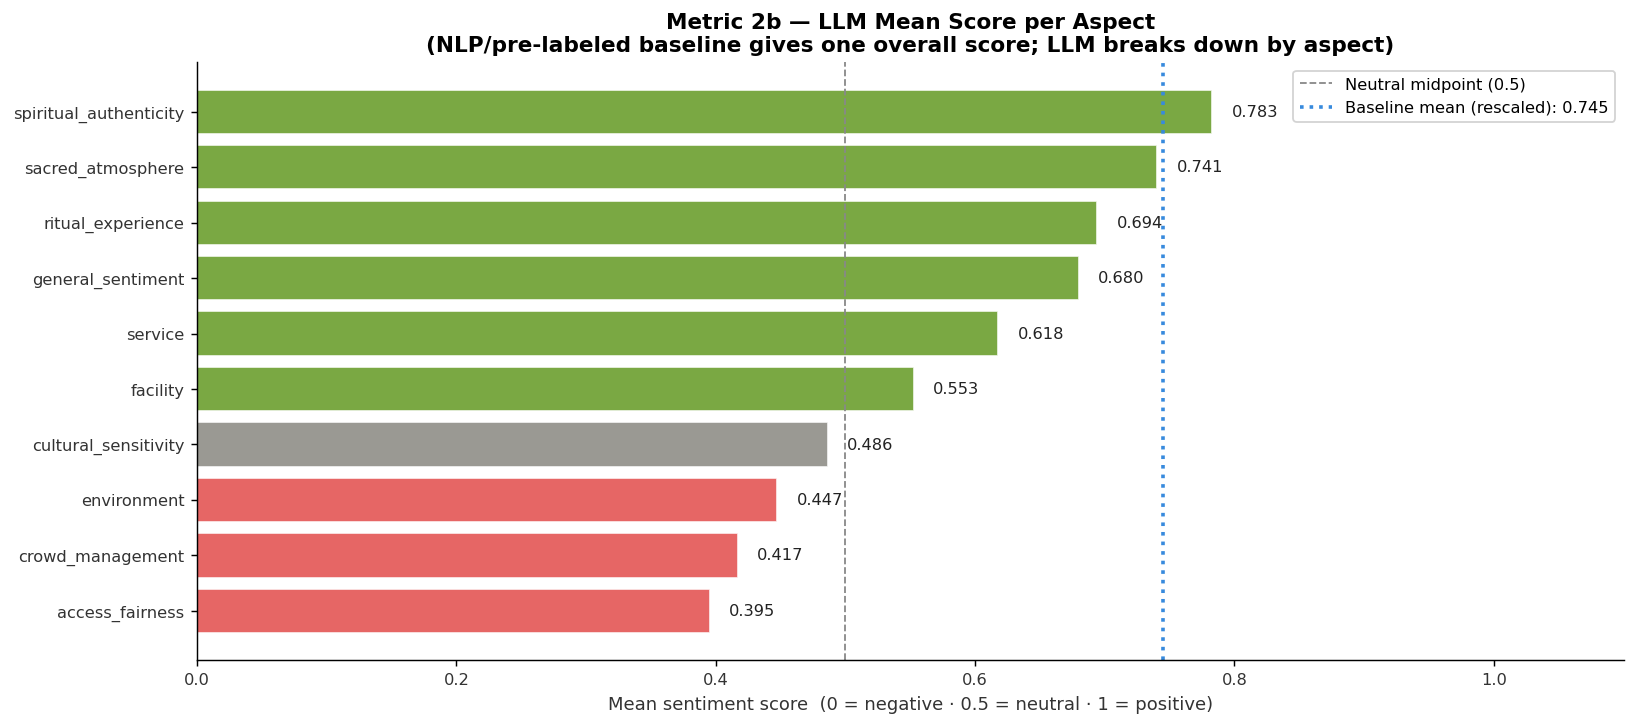

In [8]:
aspect_means = sen_core.groupby(aspect_col)[score_col].mean().sort_values(ascending=False)
aspect_order  = aspect_means.index.tolist()
bar_colors    = [PALETTE['pos'] if v >= 0.55 else PALETTE['neg'] if v <= 0.45 else PALETTE['neu']
                 for v in aspect_means.values]

fig, ax = plt.subplots(figsize=(13, max(5, len(aspect_order) * 0.45 + 1.5)))
bars = ax.barh(aspect_order, aspect_means.values, color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(0.5, color='#888888', linestyle='--', linewidth=1.0, label='Neutral midpoint (0.5)')
ax.set_xlim(0, 1.1)
ax.set_xlabel('Mean sentiment score  (0 = negative · 0.5 = neutral · 1 = positive)',
              fontsize=10, color='#333333')
ax.set_title('Metric 2b — LLM Mean Score per Aspect\n'
             '(NLP/pre-labeled baseline gives one overall score; LLM breaks down by aspect)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelcolor='#333333', labelsize=9)
ax.invert_yaxis()
for bar, val in zip(bars, aspect_means.values):
    ax.text(min(bar.get_width() + 0.015, 1.05),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, color='#222222')

# NLP/baseline reference line
nlp_ref_raw    = raw['vader_compound'].mean()
nlp_ref_scaled = (nlp_ref_raw + 1) / 2 if raw['vader_compound'].between(-1, 1).all() else nlp_ref_raw
ax.axvline(nlp_ref_scaled, color=PALETTE['nlp'], linestyle=':', linewidth=2.0,
           label=f'Baseline mean (rescaled): {nlp_ref_scaled:.3f}')
ax.legend(fontsize=9, frameon=True, framealpha=0.85, edgecolor='#cccccc')

plt.tight_layout(pad=2.0)
plt.savefig('fig2b_aspect_scores.png', bbox_inches='tight')
plt.show()


## Metric 3 — Semantic Network Analysis
### 3a. Network topology metrics

In [9]:
def network_metrics(G, label='Graph'):
    G_un    = G.to_undirected() if G.is_directed() else G
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    degree_cent = nx.degree_centrality(G_un)
    top_node    = max(degree_cent, key=degree_cent.get)
    top_cent    = degree_cent[top_node]
    degrees     = [d for _, d in G_un.degree()]
    deg_counts  = np.array(list(Counter(degrees).values()), dtype=float)
    shannon     = scipy_entropy(deg_counts / deg_counts.sum(), base=2)
    largest_cc  = max(nx.connected_components(G_un), key=len)
    G_sub       = G_un.subgraph(largest_cc)
    avg_clust   = nx.average_clustering(G_sub)
    density     = nx.density(G_un)
    avg_degree  = np.mean(degrees)
    return {
        'Nodes':                    n_nodes,
        'Edges':                    n_edges,
        'Core node':                top_node,
        'Core degree centrality':   round(top_cent, 4),
        'Shannon entropy (bits)':   round(shannon, 4),
        'Avg clustering coeff':     round(avg_clust, 4),
        'Network density':          round(density, 6),
        'Avg degree':               round(avg_degree, 2),
    }

nlp_metrics = network_metrics(G_nlp, 'NLP')
llm_metrics = network_metrics(G_llm, 'LLM')

comparison = pd.DataFrame({
    'NLP (co-occurrence)':   nlp_metrics,
    'LLM (typed relations)': llm_metrics,
})
print('=== Metric 3: Semantic Network Comparison ===')
print(comparison.to_string())
comparison


=== Metric 3: Semantic Network Comparison ===
                       NLP (co-occurrence) LLM (typed relations)
Nodes                                 1257                  5110
Edges                                 8590                  5308
Core node                            nepal   non-hindu entry ban
Core degree centrality              0.3479                0.0348
Shannon entropy (bits)              4.6473                1.4716
Avg clustering coeff                0.8029                0.0209
Network density                   0.010882                0.0004
Avg degree                           13.67                  2.05


,NLP (co-occurrence),LLM (typed relations)
Nodes,1257,5110
Edges,8590,5308
Core node,nepal,non-hindu entry ban
Core degree centrality,0.3479,0.0348
Shannon entropy (bits),4.6473,1.4716
Avg clustering coeff,0.8029,0.0209
Network density,0.010882,0.0004
Avg degree,13.67,2.05


### 3b. Degree distribution — NLP vs LLM

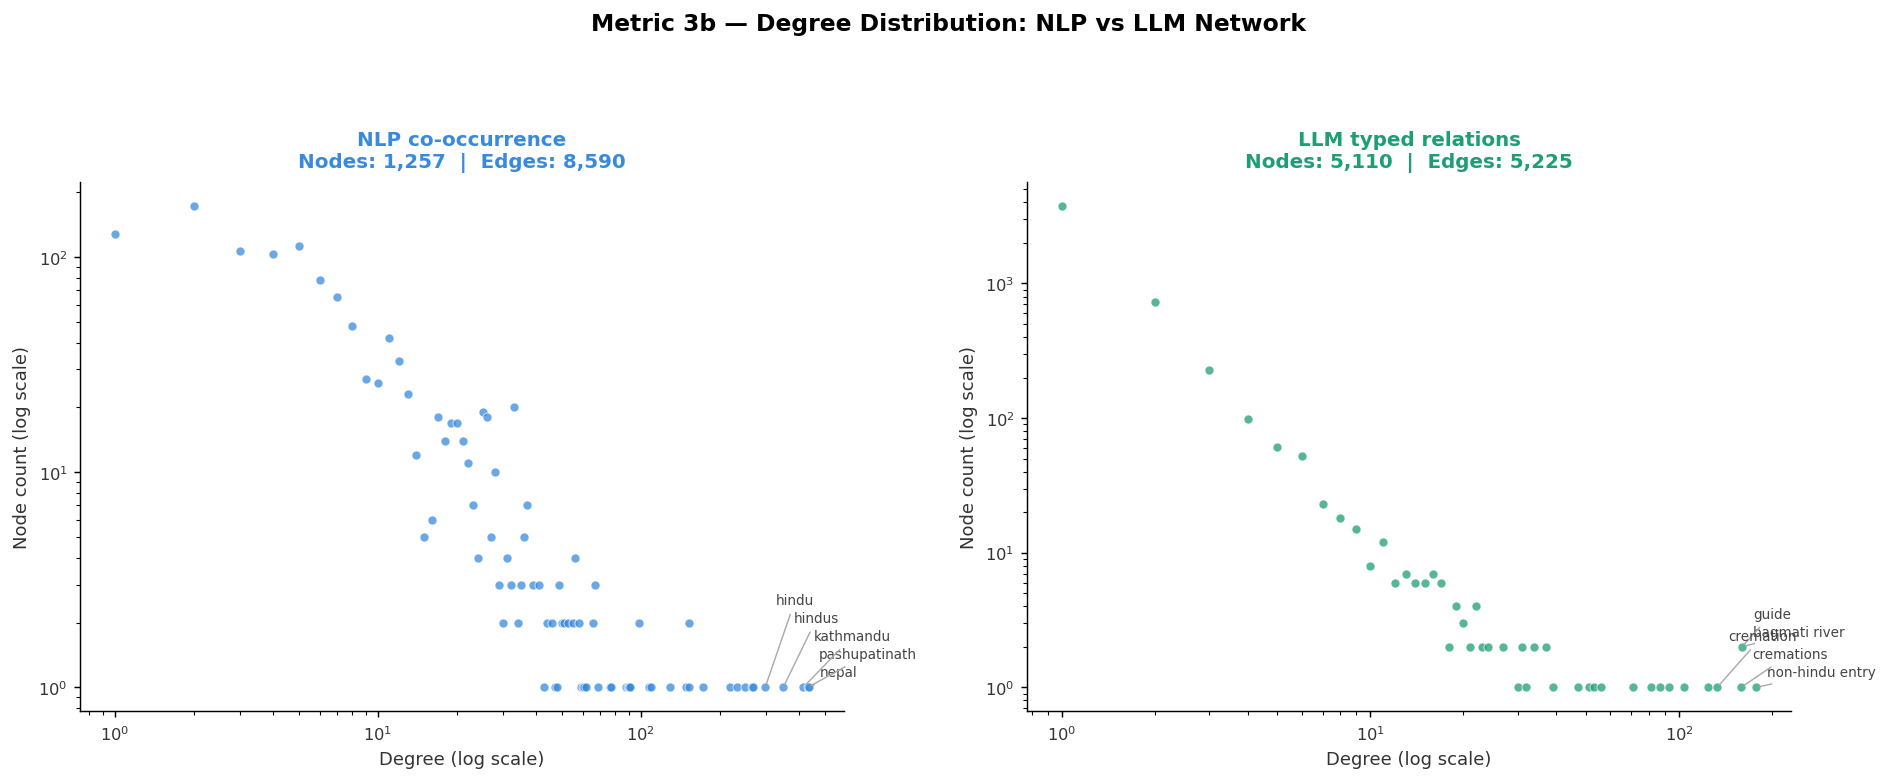

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Metric 3b — Degree Distribution: NLP vs LLM Network',
             fontweight='bold', fontsize=13, y=1.02)

for ax, G, color, label in [
    (axes[0], G_nlp,                 PALETTE['nlp'], 'NLP co-occurrence'),
    (axes[1], G_llm.to_undirected(), PALETTE['llm'], 'LLM typed relations'),
]:
    degrees   = [d for _, d in G.degree()]
    deg_count = Counter(degrees)
    x = sorted(deg_count.keys())
    y = [deg_count[k] for k in x]
    ax.scatter(x, y, color=color, alpha=0.75, s=25, edgecolors='white', linewidths=0.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree (log scale)', fontsize=10, color='#333333')
    ax.set_ylabel('Node count (log scale)', fontsize=10, color='#333333')
    ax.tick_params(axis='both', labelcolor='#333333', labelsize=9)
    ax.set_title(f'{label}\nNodes: {G.number_of_nodes():,}  |  Edges: {G.number_of_edges():,}',
                 color=color, fontsize=11, pad=8)
    # Annotate only top-5 nodes, with offset to avoid overlap
    top5 = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:5]
    used_y = []
    for node, deg in top5:
        y_val = deg_count.get(deg, 1)
        # Stagger offsets to avoid overlap
        y_offset = 6 if not used_y else (6 + used_y.count(y_val) * 10)
        used_y.append(y_val)
        ax.annotate(
            str(node)[:16],
            (deg, y_val),
            fontsize=7.5, color='#444444',
            xytext=(6, y_offset), textcoords='offset points',
            arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8),
        )

plt.tight_layout(pad=2.0)
plt.savefig('fig3b_degree_distribution.png', bbox_inches='tight')
plt.show()


### 3c. LLM relation type breakdown

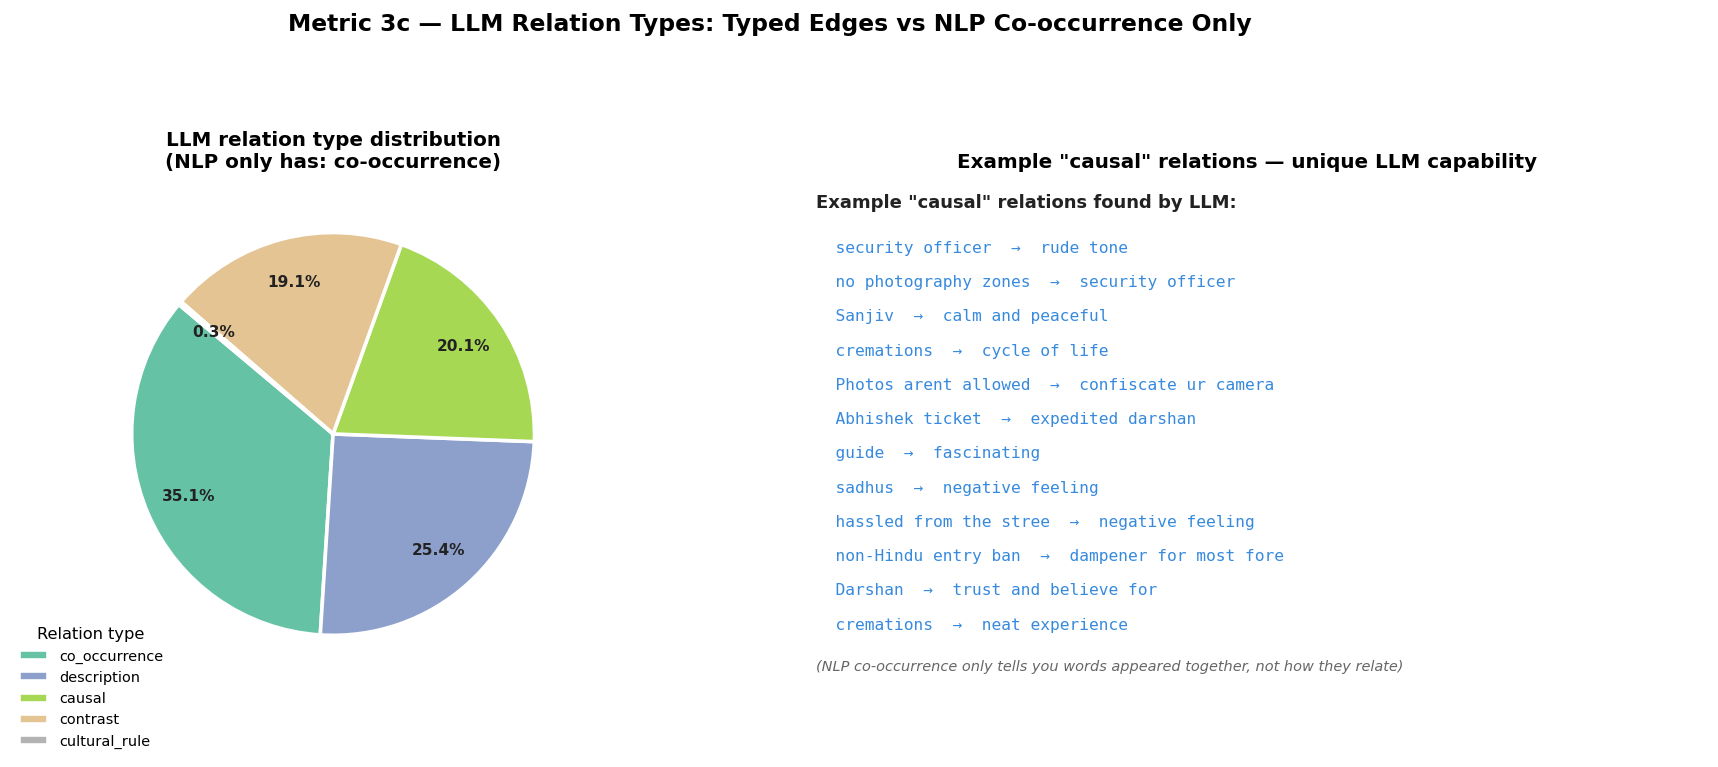

In [11]:
rel_counts = rel[rel_type_col].value_counts()
rel_cmap   = plt.cm.get_cmap('Set2', max(len(rel_counts), 3))
rel_colors = [mcolors.to_hex(rel_cmap(i)) for i in range(len(rel_counts))]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Metric 3c — LLM Relation Types: Typed Edges vs NLP Co-occurrence Only',
             fontweight='bold', fontsize=13, y=1.02)

# Pie: suppress labels on chart, use legend instead to avoid overlap
wedges, _, autotexts = axes[0].pie(
    rel_counts.values, labels=None, colors=rel_colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.78)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_color('#222222')
    at.set_fontweight('bold')
axes[0].legend(
    wedges, rel_counts.index,
    title='Relation type', fontsize=8, title_fontsize=9,
    loc='lower left', bbox_to_anchor=(-0.15, -0.15),
    framealpha=0.9, edgecolor='#cccccc')
axes[0].set_title('LLM relation type distribution\n(NLP only has: co-occurrence)',
                  fontsize=11, pad=8)

# Show example relations from top/causal type
top_rel = rel_counts.index[0]
causal_rel = 'causal' if 'causal' in rel_counts.index else top_rel
sample_chains = rel[rel[rel_type_col] == causal_rel][[rel_source_col, rel_target_col]].head(12)

axes[1].axis('off')
axes[1].set_facecolor('#F5F7FA')
y = 0.95
axes[1].text(0.03, y, f'Example \"{causal_rel}\" relations found by LLM:',
             fontsize=10, fontweight='bold', transform=axes[1].transAxes, color='#222222')
y -= 0.09
for _, row in sample_chains.iterrows():
    axes[1].text(0.03, y,
                 f"  {str(row[rel_source_col])[:22]}  →  {str(row[rel_target_col])[:22]}",
                 fontsize=9, color=PALETTE['nlp'], transform=axes[1].transAxes,
                 family='monospace')
    y -= 0.068
    if y < 0.06:
        break
axes[1].text(0.03, 0.03,
             '(NLP co-occurrence only tells you words appeared together, not how they relate)',
             fontsize=8, color='#666666', transform=axes[1].transAxes, style='italic')
axes[1].set_title(f'Example \"{causal_rel}\" relations — unique LLM capability',
                  fontsize=11, pad=8)

plt.tight_layout(pad=2.0)
plt.savefig('fig3c_relation_types.png', bbox_inches='tight')
plt.show()


### 3d. ★ Connection Graph — NLP vs LLM Side-by-Side

- **Left (blue)** — NLP co-occurrence: star-shaped, one edge type (frequency weight)
- **Right (teal)** — LLM typed-relation: distributed clusters, nodes coloured by entity type, multiple edge types


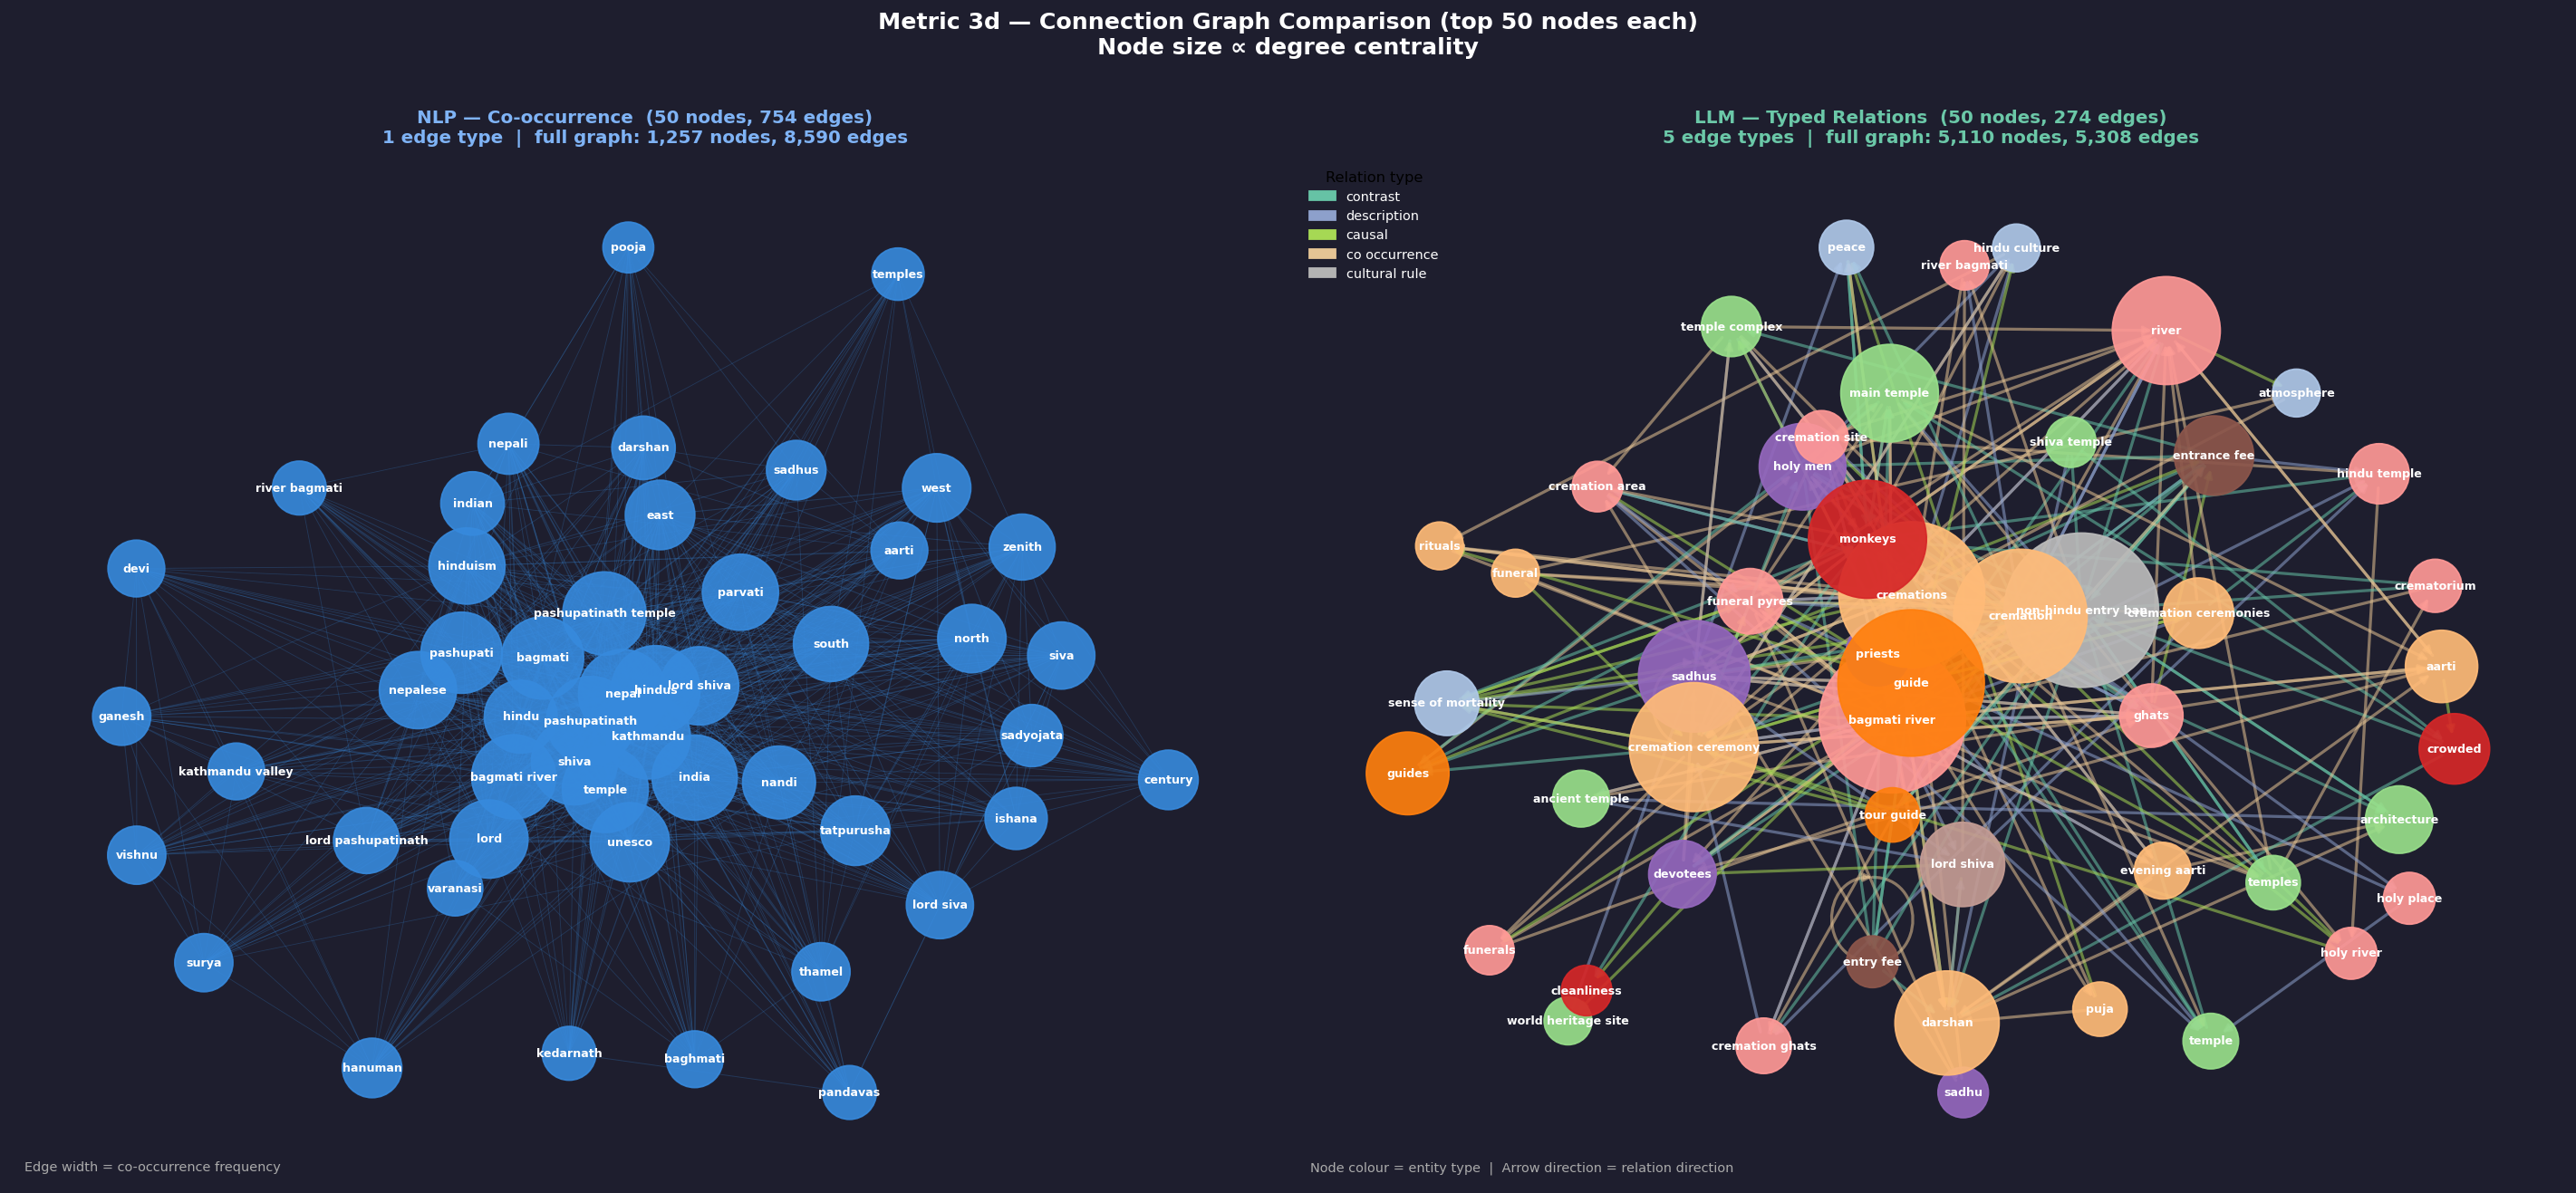

Connection graph saved.


In [15]:
TOP_N = 50  # top nodes by degree shown in each panel

top_nlp_nodes = [n for n, _ in sorted(G_nlp.degree(), key=lambda x: x[1], reverse=True)[:TOP_N]]
top_llm_nodes = [n for n, _ in sorted(G_llm.to_undirected().degree(),
                                       key=lambda x: x[1], reverse=True)[:TOP_N]]
G_nlp_sub = G_nlp.subgraph(top_nlp_nodes)
G_llm_sub = G_llm.subgraph(top_llm_nodes)

# Build dynamic colour maps from actual data
unique_types = ent[entity_type_col].str.lower().unique()
cmap_nodes   = plt.cm.get_cmap('tab20', max(len(unique_types), 2))
type_node_colors = {t: mcolors.to_hex(cmap_nodes(i)) for i, t in enumerate(unique_types)}

unique_rels = rel[rel_type_col].unique()
cmap_edges  = plt.cm.get_cmap('Set2', max(len(unique_rels), 2))
edge_color_map = {r: mcolors.to_hex(cmap_edges(i)) for i, r in enumerate(unique_rels)}

entity_type_map = (ent.set_index(entity_name_col)[entity_type_col]
                   .str.lower().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.patch.set_facecolor('#1E1E2E')  # dark bg for contrast
fig.suptitle(
    f'Metric 3d — Connection Graph Comparison (top {TOP_N} nodes each)'
    f'\nNode size ∝ degree centrality',
    fontsize=14, fontweight='bold', y=1.01, color='white'
)

# ── NLP (left) ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#1E1E2E')
pos_nlp = nx.spring_layout(G_nlp_sub, seed=42, k=1.6)
deg_nlp = dict(G_nlp_sub.degree())
node_sizes_nlp = [max(deg_nlp[n] * 60, 80) for n in G_nlp_sub.nodes()]
ew_nlp  = [G_nlp_sub[u][v].get('weight', 1) for u, v in G_nlp_sub.edges()]
mw      = max(ew_nlp) if ew_nlp else 1
ew_nlp_scaled = [0.4 + 3.5 * (w / mw) for w in ew_nlp]

nx.draw_networkx_edges(G_nlp_sub, pos_nlp, width=ew_nlp_scaled,
                       edge_color=PALETTE['nlp'], alpha=0.25, ax=ax)
nx.draw_networkx_nodes(G_nlp_sub, pos_nlp, node_size=node_sizes_nlp,
                       node_color=PALETTE['nlp'], alpha=0.90, ax=ax)
# Draw labels with dark outline for legibility on dark bg
nx.draw_networkx_labels(G_nlp_sub, pos_nlp, font_size=7, font_color='white',
                        font_weight='bold', ax=ax)
ax.set_title(
    f'NLP — Co-occurrence  ({G_nlp_sub.number_of_nodes()} nodes, {G_nlp_sub.number_of_edges()} edges)\n'
    f'1 edge type  |  full graph: {G_nlp.number_of_nodes():,} nodes, {G_nlp.number_of_edges():,} edges',
    color='#7FB3F5', fontsize=11, pad=10)
ax.axis('off')
ax.text(0.01, 0.01, 'Edge width = co-occurrence frequency', transform=ax.transAxes,
        fontsize=8, color='#AAAAAA')

# ── LLM (right) ───────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1E1E2E')
pos_llm = nx.spring_layout(G_llm_sub, seed=42, k=1.4)
deg_llm_full   = dict(G_llm.to_undirected().degree())
node_sizes_llm = [max(deg_llm_full.get(n, 1) * 50, 80) for n in G_llm_sub.nodes()]
node_colors_llm = [type_node_colors.get(entity_type_map.get(n, entity_type_map.get(n.title(), '')), '#BBBBBB')
                   for n in G_llm_sub.nodes()]
edge_colors_llm = [edge_color_map.get(G_llm.edges[u, v].get('relation', unique_rels[0]), 'gray')
                   for u, v in G_llm_sub.edges()]

nx.draw_networkx_edges(G_llm_sub, pos_llm, edge_color=edge_colors_llm,
                       alpha=0.55, width=1.8, arrows=True, arrowsize=10, ax=ax2)
nx.draw_networkx_nodes(G_llm_sub, pos_llm, node_color=node_colors_llm,
                       node_size=node_sizes_llm, alpha=0.92, ax=ax2)
nx.draw_networkx_labels(G_llm_sub, pos_llm, font_size=7, font_color='white',
                        font_weight='bold', ax=ax2)

edge_handles = [mpatches.Patch(color=c, label=r.replace('_', ' '))
                for r, c in edge_color_map.items()]
ax2.legend(handles=edge_handles, title='Relation type', fontsize=8,
           loc='upper left', framealpha=0.85, title_fontsize=9,
           facecolor='#2E2E3E', edgecolor='#555566', labelcolor='white',
    )

n_rel_types = rel[rel_type_col].nunique()
ax2.set_title(
    f'LLM — Typed Relations  ({G_llm_sub.number_of_nodes()} nodes, {G_llm_sub.number_of_edges()} edges)\n'
    f'{n_rel_types} edge types  |  full graph: {G_llm.number_of_nodes():,} nodes, {G_llm.number_of_edges():,} edges',
    color='#6BC8A8', fontsize=11, pad=10)
ax2.axis('off')
ax2.text(0.01, 0.01, 'Node colour = entity type  |  Arrow direction = relation direction',
         transform=ax2.transAxes, fontsize=8, color='#AAAAAA')

plt.tight_layout()
plt.savefig('fig3d_connection_graph_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Connection graph saved.')


### 3e. Network metrics bar chart (NLP vs LLM, normalised)

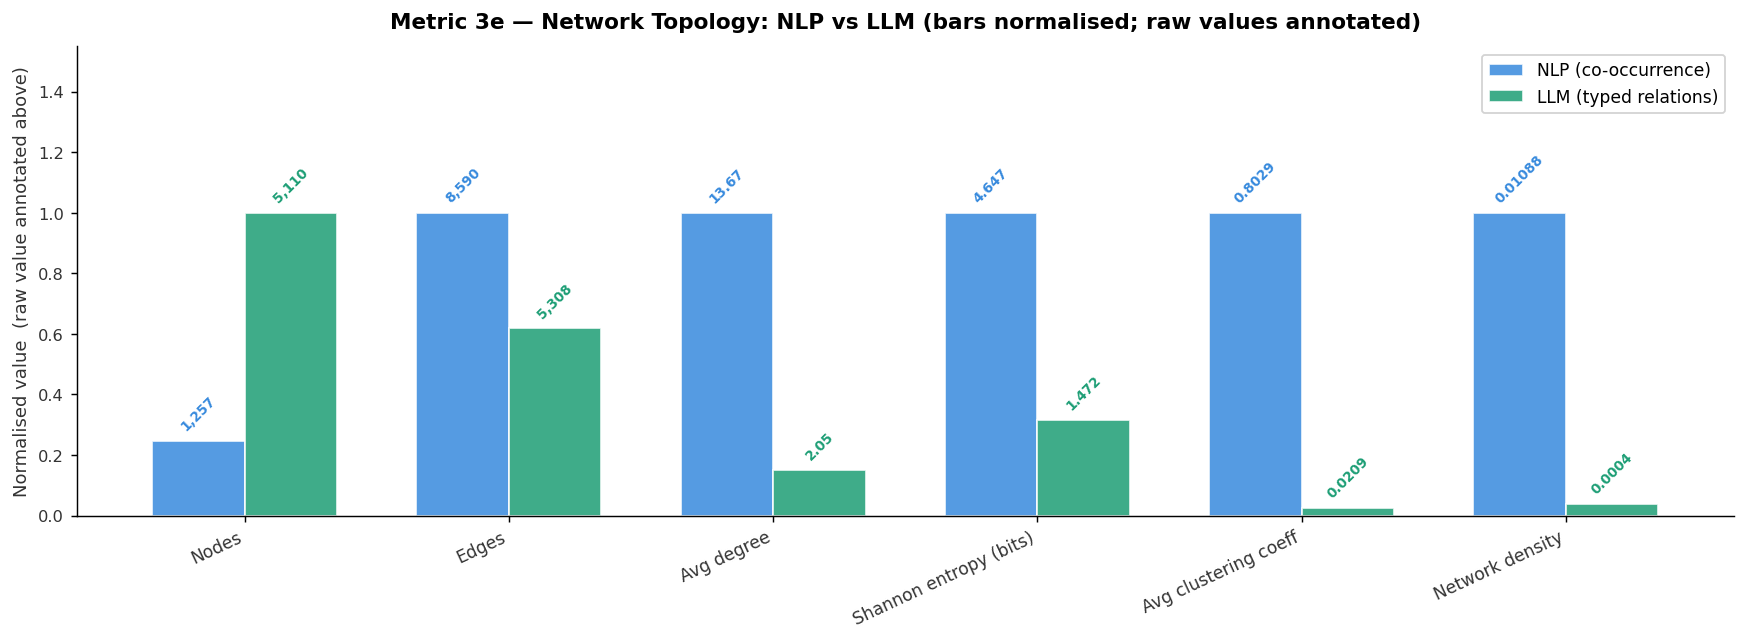

In [13]:
metric_labels = ['Nodes', 'Edges', 'Avg degree', 'Shannon entropy (bits)',
                 'Avg clustering coeff', 'Network density']
nlp_vals = [float(nlp_metrics[m]) for m in metric_labels]
llm_vals = [float(llm_metrics[m]) for m in metric_labels]

def norm_pair(a, b):
    mx = max(a, b)
    return (a / mx if mx else 0), (b / mx if mx else 0)

nlp_norm, llm_norm = [], []
for nv, lv in zip(nlp_vals, llm_vals):
    n, l = norm_pair(nv, lv)
    nlp_norm.append(n); llm_norm.append(l)

x = np.arange(len(metric_labels)); w = 0.35
fig, ax = plt.subplots(figsize=(14, 5.5))
b1 = ax.bar(x - w/2, nlp_norm, w, label='NLP (co-occurrence)',   color=PALETTE['nlp'], alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, llm_norm, w, label='LLM (typed relations)', color=PALETTE['llm'], alpha=0.85, edgecolor='white')
for bar, rv in zip(b1, nlp_vals):
    label_str = f'{rv:,.4g}'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.025,
            label_str, ha='center', fontsize=7.5, color=PALETTE['nlp'],
            fontweight='bold', rotation=45, va='bottom')
for bar, rv in zip(b2, llm_vals):
    label_str = f'{rv:,.4g}'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.025,
            label_str, ha='center', fontsize=7.5, color=PALETTE['llm'],
            fontweight='bold', rotation=45, va='bottom')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, rotation=25, ha='right', fontsize=9.5, color='#333333')
ax.tick_params(axis='y', labelcolor='#333333', labelsize=9)
ax.set_ylabel('Normalised value  (raw value annotated above)', fontsize=10, color='#333333')
ax.set_title('Metric 3e — Network Topology: NLP vs LLM (bars normalised; raw values annotated)',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=9.5, frameon=True, framealpha=0.85, edgecolor='#cccccc')
ax.set_ylim(0, 1.55)
plt.tight_layout(pad=2.5)
plt.savefig('fig3e_network_metrics_bar.png', bbox_inches='tight')
plt.show()


## Final — Summary Comparison Table

In [14]:
summary = pd.DataFrame([
    {'Category': 'Entity Recognition', 'Metric': 'Total entities extracted',
     'NLP': f'{len(nlp_ent):,}', 'LLM': f'{len(ent):,}',
     'Note': 'NLP: all NE tokens; LLM: heritage-specific instances'},
    {'Category': 'Entity Recognition', 'Metric': 'Entity type categories',
     'NLP': f'{nlp_type_counts.nunique()} (generic)',
     'LLM': f'{ent[entity_type_col].nunique()} (domain-specific)',
     'Note': 'LLM schema user-defined; NLP types are fixed (NLTK)'},
    {'Category': 'Sentiment Analysis', 'Metric': 'Task type',
     'NLP': 'Overall polarity (VADER)', 'LLM': f'Aspect-level ({sen[aspect_col].nunique()} dims)',
     'Note': 'Different granularity — not directly comparable'},
    {'Category': 'Sentiment Analysis', 'Metric': 'Sentiment records produced',
     'NLP': f'{len(raw):,} (one per review)',
     'LLM': f'{len(sen):,} (aspect × review)',
     'Note': 'LLM generates multiple records per review'},
    {'Category': 'Sentiment Analysis', 'Metric': 'Aspect dimensions',
     'NLP': '0 (polarity only)', 'LLM': f'{sen[aspect_col].nunique()} aspects',
     'Note': 'Critical advantage for fine-grained experience research'},
    {'Category': 'Semantic Network', 'Metric': 'Nodes',
     'NLP': f"{nlp_metrics['Nodes']:,}", 'LLM': f"{llm_metrics['Nodes']:,}",
     'Note': 'NLP inflated by all word co-occurrences'},
    {'Category': 'Semantic Network', 'Metric': 'Edges',
     'NLP': f"{nlp_metrics['Edges']:,}", 'LLM': f"{llm_metrics['Edges']:,}",
     'Note': 'LLM edges are typed (causal, description, etc.)'},
    {'Category': 'Semantic Network', 'Metric': 'Core node degree centrality',
     'NLP': str(nlp_metrics['Core degree centrality']),
     'LLM': str(llm_metrics['Core degree centrality']),
     'Note': 'Higher = more densely connected core'},
    {'Category': 'Semantic Network', 'Metric': 'Shannon entropy (bits)',
     'NLP': str(nlp_metrics['Shannon entropy (bits)']),
     'LLM': str(llm_metrics['Shannon entropy (bits)']),
     'Note': 'Higher = richer, more distributed semantic structure'},
    {'Category': 'Semantic Network', 'Metric': 'Relation types',
     'NLP': '1 (co-occurrence only)',
     'LLM': f"{rel[rel_type_col].nunique()} (typed)",
     'Note': 'Typed edges enable causal / mechanism tracing'},
])

print(summary.to_string(index=False))
summary.to_csv('nlp_vs_llm_comparison.csv', index=False)
print('\nSaved: nlp_vs_llm_comparison.csv')
print('\nFigures:')
figs = ['fig1a_entity_taxonomy.png', 'fig2a_sentiment_comparison.png',
        'fig2b_aspect_scores.png', 'fig3b_degree_distribution.png',
        'fig3c_relation_types.png', 'fig3d_connection_graph_comparison.png',
        'fig3e_network_metrics_bar.png', 'nlp_vs_llm_comparison.csv']
for f in figs:
    print(f'  {f}')
summary


          Category                      Metric                      NLP                     LLM                                                    Note
Entity Recognition    Total entities extracted                    5,685                  11,314    NLP: all NE tokens; LLM: heritage-specific instances
Entity Recognition      Entity type categories              6 (generic)    17 (domain-specific)     LLM schema user-defined; NLP types are fixed (NLTK)
Sentiment Analysis                   Task type Overall polarity (VADER)  Aspect-level (12 dims)         Different granularity — not directly comparable
Sentiment Analysis  Sentiment records produced   2,500 (one per review) 6,232 (aspect × review)               LLM generates multiple records per review
Sentiment Analysis           Aspect dimensions        0 (polarity only)              12 aspects Critical advantage for fine-grained experience research
  Semantic Network                       Nodes                    1,257                 

,Category,Metric,NLP,LLM,Note
0,Entity Recognition,Total entities extracted,"5,685","11,314",NLP: all NE tokens; LLM: heritage-specific ins...
1,Entity Recognition,Entity type categories,6 (generic),17 (domain-specific),LLM schema user-defined; NLP types are fixed (...
2,Sentiment Analysis,Task type,Overall polarity (VADER),Aspect-level (12 dims),Different granularity — not directly comparable
3,Sentiment Analysis,Sentiment records produced,"2,500 (one per review)","6,232 (aspect × review)",LLM generates multiple records per review
4,Sentiment Analysis,Aspect dimensions,0 (polarity only),12 aspects,Critical advantage for fine-grained experience...
5,Semantic Network,Nodes,"1,257","5,110",NLP inflated by all word co-occurrences
6,Semantic Network,Edges,"8,590","5,308","LLM edges are typed (causal, description, etc.)"
7,Semantic Network,Core node degree centrality,0.3479,0.0348,Higher = more densely connected core
8,Semantic Network,Shannon entropy (bits),4.6473,1.4716,"Higher = richer, more distributed semantic str..."
9,Semantic Network,Relation types,1 (co-occurrence only),5 (typed),Typed edges enable causal / mechanism tracing
